# Notebook 03 - Exploratory Analysis

**Project:** What Does Poor Service Cost a Business? - Customer Operations Intelligence

**Objective:** Explore all four clean tables to understand the shape of the business - revenue trends, customer segment behaviour, service ticket patterns, and operational performance. Every finding is followed by its business implication.

**Inputs:**
- `data/processed/transactions_clean.csv`
- `data/processed/customers_clean.csv`
- `data/processed/tickets_clean.csv`
- `data/processed/operations_clean.csv`

**Output:** Key findings and visualisations that feed into Notebooks 04 and 05.

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Chart style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

COLORS = {
    'primary':   '#1D9E75',
    'secondary': '#185FA5',
    'warning':   '#BA7517',
    'danger':    '#A32D2D',
    'neutral':   '#5F5E5A'
}

print('Libraries loaded.')

Libraries loaded.


## 1. Load Clean Data

In [2]:
trans   = pd.read_csv('data/processed/transactions_clean.csv', low_memory=False)
cust    = pd.read_csv('data/processed/customers_clean.csv')
tickets = pd.read_csv('data/processed/tickets_clean.csv')
ops     = pd.read_csv('data/processed/operations_clean.csv')

# Parse dates
trans['invoice_date']      = pd.to_datetime(trans['invoice_date'])
cust['acquisition_date']   = pd.to_datetime(cust['acquisition_date'])
tickets['ticket_date']     = pd.to_datetime(tickets['ticket_date'])

# Derived time columns
trans['year']      = trans['invoice_date'].dt.year
trans['month']     = trans['invoice_date'].dt.month
trans['month_str'] = trans['invoice_date'].dt.to_period('M').astype(str)
tickets['month']   = tickets['ticket_date'].dt.month
tickets['year']    = tickets['ticket_date'].dt.year

# Exclude guest transactions for customer-level analysis
trans_known = trans[trans['customer_id'] != 'GUEST']

print('All clean tables loaded.')
print(f'Transactions: {len(trans):,} | Customers: {len(cust):,} | Tickets: {len(tickets):,} | Ops: {len(ops):,}')

All clean tables loaded.
Transactions: 1,041,670 | Customers: 5,942 | Tickets: 15,000 | Ops: 64


---
## 2. Revenue Overview

### 2.1 Key Revenue Metrics

In [3]:
total_revenue     = trans['revenue'].sum()
total_orders      = trans['invoice'].nunique()
avg_order_value   = trans.groupby('invoice')['revenue'].sum().mean()
total_customers   = trans_known['customer_id'].nunique()
guest_pct         = trans['is_guest'].mean() * 100

print('=' * 50)
print('  REVENUE SUMMARY')
print('=' * 50)
print(f'  Total Revenue:        £{total_revenue:>12,.2f}')
print(f'  Total Orders:         {total_orders:>12,}')
print(f'  Avg Order Value:      £{avg_order_value:>12,.2f}')
print(f'  Identified Customers: {total_customers:>12,}')
print(f'  Guest Transactions:   {guest_pct:>11.1f}%')
print('=' * 50)

  REVENUE SUMMARY
  Total Revenue:        £20,972,594.57
  Total Orders:               40,077
  Avg Order Value:      £      523.31
  Identified Customers:        5,878
  Guest Transactions:          22.7%


### 2.2 Monthly Revenue Trend

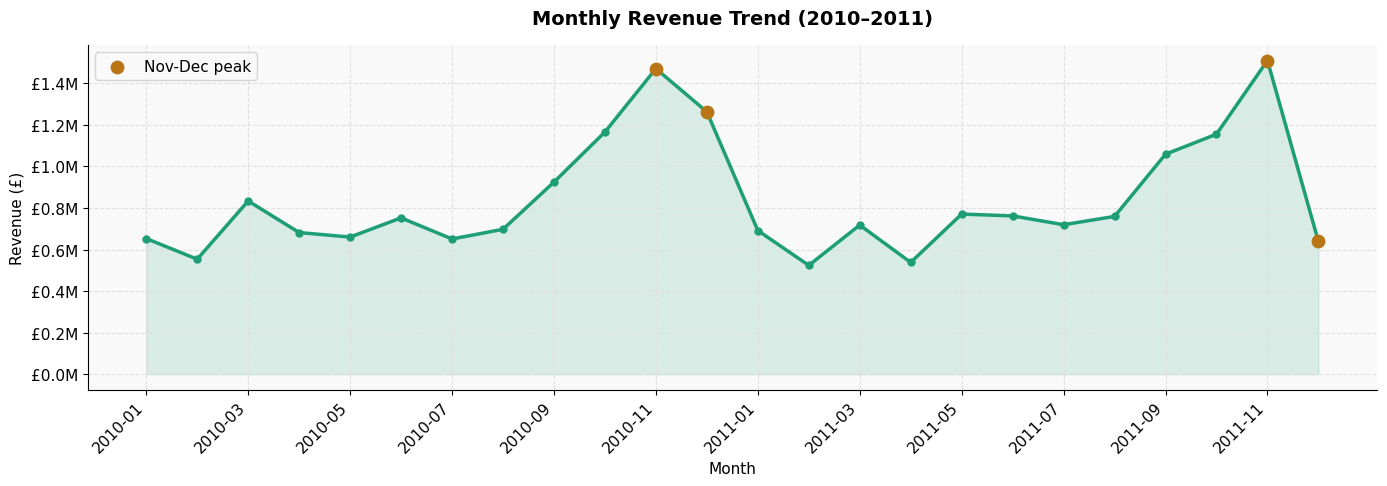

Chart saved.


In [4]:
monthly_rev = (
    trans[trans['year'].isin([2010, 2011])]
    .groupby('month_str')['revenue']
    .sum()
    .reset_index()
    .sort_values('month_str')
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly_rev['month_str'], monthly_rev['revenue'],
                alpha=0.15, color=COLORS['primary'])
ax.plot(monthly_rev['month_str'], monthly_rev['revenue'],
        color=COLORS['primary'], linewidth=2.5, marker='o', markersize=5)

# Highlight Nov-Dec peaks
peak_months = monthly_rev[monthly_rev['month_str'].str.endswith(('-11', '-12'))]
ax.scatter(peak_months['month_str'], peak_months['revenue'],
           color=COLORS['warning'], zorder=5, s=80, label='Nov-Dec peak')

ax.set_title('Monthly Revenue Trend (2010–2011)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
ax.set_xticks(range(0, len(monthly_rev), 2))
ax.set_xticklabels(monthly_rev['month_str'].iloc[::2], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('data/processed/chart_01_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

In [5]:
print('--- FINDING 2.2 ---')
print('Revenue peaks sharply in November and December every year.')
peak_rev = monthly_rev[monthly_rev['month_str'].str.endswith(('-11','-12'))]['revenue'].mean()
avg_rev  = monthly_rev['revenue'].mean()
print(f'Average monthly revenue:      £{avg_rev:,.0f}')
print(f'Average Nov-Dec revenue:      £{peak_rev:,.0f}')
print(f'Peak premium over average:    {((peak_rev/avg_rev)-1)*100:.0f}%')
print()
print('IMPLICATION:')
print('The business is heavily seasonal. A disproportionate share of annual')
print('revenue is generated in Q4. Any operational failure or service breakdown')
print('during November-December carries outsized financial risk compared to')
print('the same failure in other months.')
print()
print('RECOMMENDATION:')
print('SLA targets should be tightened and staffing increased specifically')
print('for Q4. Service failures in peak months must be treated as critical.')
print()
print('RISK OF INACTION:')
print('Maintaining flat operational capacity year-round means the business')
print('is structurally under-resourced during its most revenue-critical period.')

--- FINDING 2.2 ---
Revenue peaks sharply in November and December every year.
Average monthly revenue:      £839,455
Average Nov-Dec revenue:      £1,220,295
Peak premium over average:    45%

IMPLICATION:
The business is heavily seasonal. A disproportionate share of annual
revenue is generated in Q4. Any operational failure or service breakdown
during November-December carries outsized financial risk compared to
the same failure in other months.

RECOMMENDATION:
SLA targets should be tightened and staffing increased specifically
for Q4. Service failures in peak months must be treated as critical.

RISK OF INACTION:
Maintaining flat operational capacity year-round means the business
is structurally under-resourced during its most revenue-critical period.


### 2.3 Revenue by Country

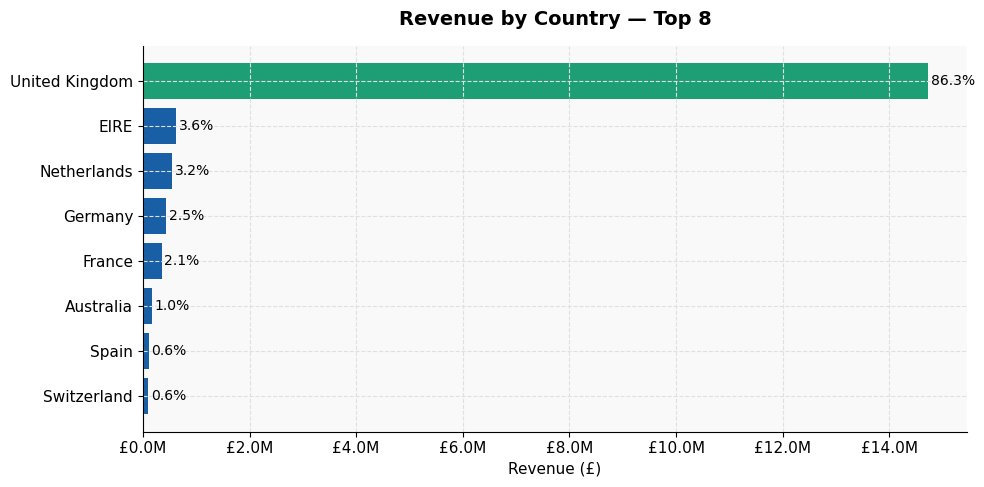

UK share of total revenue: 86.3%


In [6]:
country_rev = (
    trans_known.groupby('country')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .reset_index()
)
country_rev['revenue_pct'] = (country_rev['revenue'] / country_rev['revenue'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(country_rev['country'][::-1], country_rev['revenue'][::-1],
               color=[COLORS['primary'] if c == 'United Kingdom' else COLORS['secondary']
                      for c in country_rev['country'][::-1]])

for bar, pct in zip(bars, country_rev['revenue_pct'][::-1]):
    ax.text(bar.get_width() + 50000, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=10)

ax.set_title('Revenue by Country — Top 8', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('data/processed/chart_02_revenue_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

uk_pct = country_rev[country_rev['country']=='United Kingdom']['revenue_pct'].values[0]
print(f'UK share of total revenue: {uk_pct}%')

In [7]:
print('--- FINDING 2.3 ---')
print(f'UK generates {uk_pct}% of total revenue.')
print()
print('IMPLICATION:')
print('The business has extreme geographic concentration risk. A single market')
print('accounts for the vast majority of revenue. Economic disruption, regulatory')
print('change, or a major service failure in the UK market has no buffer.')
print()
print('RECOMMENDATION:')
print('Germany, Netherlands and France show meaningful revenue potential.')
print('A targeted expansion strategy in these markets would reduce concentration risk.')
print()
print('RISK OF INACTION:')
print('Over-dependence on one market leaves the business structurally fragile.')
print('Any UK-specific disruption directly threatens overall business viability.')

--- FINDING 2.3 ---
UK generates 86.3% of total revenue.

IMPLICATION:
The business has extreme geographic concentration risk. A single market
accounts for the vast majority of revenue. Economic disruption, regulatory
change, or a major service failure in the UK market has no buffer.

RECOMMENDATION:
Germany, Netherlands and France show meaningful revenue potential.
A targeted expansion strategy in these markets would reduce concentration risk.

RISK OF INACTION:
Over-dependence on one market leaves the business structurally fragile.
Any UK-specific disruption directly threatens overall business viability.


---
## 3. Customer Segment Analysis

### 3.1 Segment Distribution and CLV

In [8]:
seg_summary = cust.groupby('segment').agg(
    customer_count=('customer_id', 'count'),
    avg_clv=('clv', 'mean'),
    total_clv=('clv', 'sum')
).round(2).reset_index()

seg_summary['pct_customers'] = (seg_summary['customer_count'] / seg_summary['customer_count'].sum() * 100).round(1)
seg_summary['pct_total_clv'] = (seg_summary['total_clv'] / seg_summary['total_clv'].sum() * 100).round(1)

print('CUSTOMER SEGMENT SUMMARY')
print(seg_summary.to_string(index=False))

CUSTOMER SEGMENT SUMMARY
  segment  customer_count  avg_clv   total_clv  pct_customers  pct_total_clv
Corporate            1619  8309.56 13453182.44           27.2           74.6
   Retail            3476   615.19  2138409.16           58.5           11.9
Wholesale             847  2876.22  2436160.78           14.3           13.5


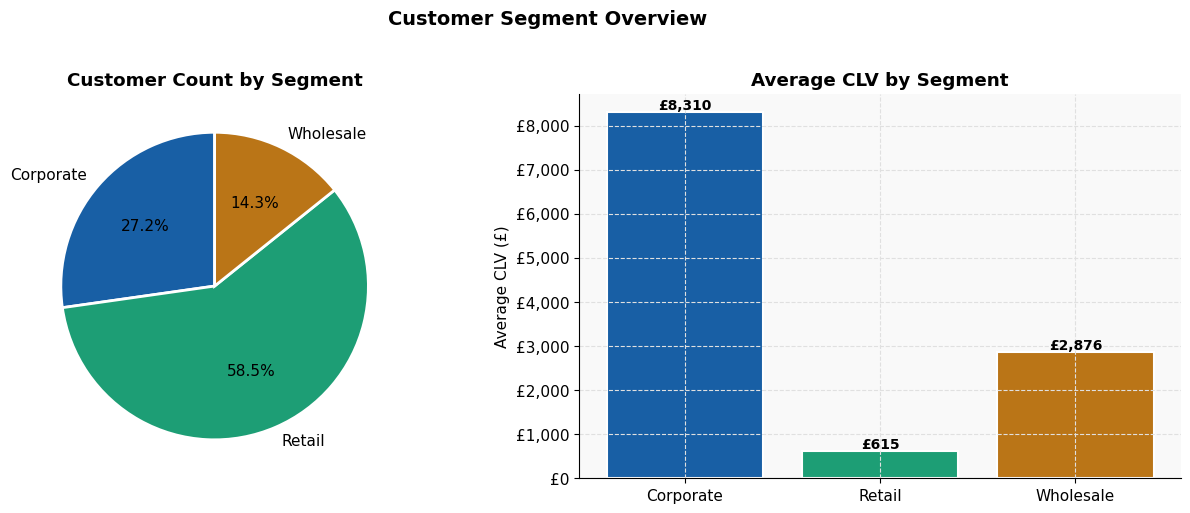

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seg_colors = [COLORS['secondary'], COLORS['primary'], COLORS['warning']]

# Pie — customer count
axes[0].pie(
    seg_summary['customer_count'],
    labels=seg_summary['segment'],
    autopct='%1.1f%%',
    colors=seg_colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Customer Count by Segment', fontweight='bold')

# Bar — average CLV
bars = axes[1].bar(
    seg_summary['segment'],
    seg_summary['avg_clv'],
    color=seg_colors,
    edgecolor='white',
    linewidth=1.5
)
for bar, val in zip(bars, seg_summary['avg_clv']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'£{val:,.0f}', ha='center', fontsize=10, fontweight='bold')

axes[1].set_title('Average CLV by Segment', fontweight='bold')
axes[1].set_ylabel('Average CLV (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.suptitle('Customer Segment Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/processed/chart_03_segment_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
corp = seg_summary[seg_summary['segment'] == 'Corporate'].iloc[0]
retail = seg_summary[seg_summary['segment'] == 'Retail'].iloc[0]

print('--- FINDING 3.1 ---')
print(f"Corporate customers are {corp['pct_customers']}% of the base but hold {corp['pct_total_clv']}% of total CLV.")
print(f"Their average CLV (£{corp['avg_clv']:,.0f}) is {corp['avg_clv']/retail['avg_clv']:.0f}x higher than Retail (£{retail['avg_clv']:,.0f}).")
print()
print('IMPLICATION:')
print('The business has a high-value minority segment that is disproportionately')
print('important to long-term revenue. Losing a small number of corporate customers')
print('has an outsized impact on total CLV compared to losing retail customers.')
print()
print('RECOMMENDATION:')
print('Corporate customers should receive differentiated service — priority SLA,')
print('dedicated account management, and proactive outreach when issues arise.')
print()
print('RISK OF INACTION:')
print('Treating corporate and retail customers identically means your most valuable')
print('segment receives no protection against churn. A single corporate account lost')
print(f"to poor service costs the equivalent of {corp['avg_clv']/retail['avg_clv']:.0f} retail customers.")

--- FINDING 3.1 ---
Corporate customers are 27.2% of the base but hold 74.6% of total CLV.
Their average CLV (£8,310) is 14x higher than Retail (£615).

IMPLICATION:
The business has a high-value minority segment that is disproportionately
important to long-term revenue. Losing a small number of corporate customers
has an outsized impact on total CLV compared to losing retail customers.

RECOMMENDATION:
Corporate customers should receive differentiated service — priority SLA,
dedicated account management, and proactive outreach when issues arise.

RISK OF INACTION:
Treating corporate and retail customers identically means your most valuable
segment receives no protection against churn. A single corporate account lost
to poor service costs the equivalent of 14 retail customers.


---
## 4. Service Ticket Analysis

### 4.1 Ticket Volume by Category

In [11]:
cat_summary = tickets.groupby('issue_category').agg(
    ticket_count=('ticket_id', 'count'),
    avg_resolution_days=('resolution_days', 'mean'),
    sla_breach_rate=('sla_breached', 'mean'),
    avg_csat=('csat_score', 'mean')
).round(2).reset_index().sort_values('ticket_count', ascending=False)

print('TICKET SUMMARY BY CATEGORY')
print(cat_summary.to_string(index=False))

TICKET SUMMARY BY CATEGORY
 issue_category  ticket_count  avg_resolution_days  sla_breach_rate  avg_csat
       Delivery          2993                 5.39             0.99      2.33
        Billing          2950                 8.35             1.00      1.96
         Refund          2580                 7.25             1.00      2.04
 Account Access          2324                 3.30             0.77      3.05
General Enquiry          2186                 2.10             0.52      3.60
 Product Defect          1967                 6.42             1.00      2.15


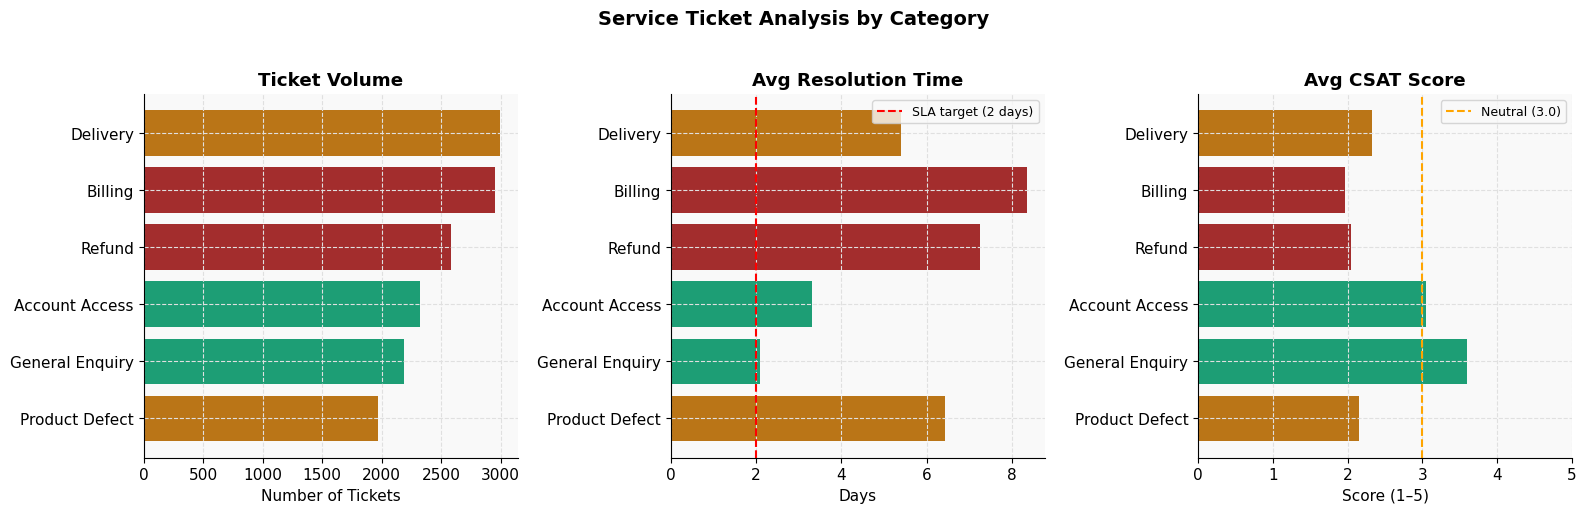

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cats = cat_summary['issue_category']
bar_colors = [
    COLORS['danger'] if c in ['Billing', 'Refund'] else
    COLORS['warning'] if c in ['Delivery', 'Product Defect'] else
    COLORS['primary']
    for c in cats
]

# Volume
axes[0].barh(cats[::-1], cat_summary['ticket_count'][::-1], color=bar_colors[::-1])
axes[0].set_title('Ticket Volume', fontweight='bold')
axes[0].set_xlabel('Number of Tickets')

# Avg resolution days
axes[1].barh(cats[::-1], cat_summary['avg_resolution_days'][::-1], color=bar_colors[::-1])
axes[1].axvline(x=2, color='red', linestyle='--', linewidth=1.5, label='SLA target (2 days)')
axes[1].set_title('Avg Resolution Time', fontweight='bold')
axes[1].set_xlabel('Days')
axes[1].legend(fontsize=9)

# Avg CSAT
axes[2].barh(cats[::-1], cat_summary['avg_csat'][::-1], color=bar_colors[::-1])
axes[2].axvline(x=3, color='orange', linestyle='--', linewidth=1.5, label='Neutral (3.0)')
axes[2].set_title('Avg CSAT Score', fontweight='bold')
axes[2].set_xlabel('Score (1–5)')
axes[2].set_xlim(0, 5)
axes[2].legend(fontsize=9)

plt.suptitle('Service Ticket Analysis by Category', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/processed/chart_04_ticket_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
billing = cat_summary[cat_summary['issue_category'] == 'Billing'].iloc[0]
general = cat_summary[cat_summary['issue_category'] == 'General Enquiry'].iloc[0]

print('--- FINDING 4.1 ---')
print(f"Billing complaints have the worst resolution time ({billing['avg_resolution_days']:.1f} days)")
print(f"and lowest CSAT ({billing['avg_csat']:.2f}/5) — against a 2-day SLA target.")
print(f"General Enquiries resolve in far less time with CSAT of {general['avg_csat']:.2f}.")
print()
print('IMPLICATION:')
print('Billing is the single most damaging issue category — highest volume,')
print('slowest resolution, worst satisfaction. Customers raising billing issues')
print('are experiencing both a financial problem and a poor service response.')
print('This combination is the highest churn risk in the entire ticket dataset.')
print()
print('RECOMMENDATION:')
print('Create a dedicated billing resolution path with a specialist team and')
print('a 48-hour maximum resolution commitment regardless of complexity.')
print()
print('RISK OF INACTION:')
print('Every billing complaint that takes longer than 5 days to resolve')
print('is a high-probability churn event — particularly for corporate customers')
print('whose CLV makes that churn disproportionately expensive.')

--- FINDING 4.1 ---
Billing complaints have the worst resolution time (8.3 days)
and lowest CSAT (1.96/5) — against a 2-day SLA target.
General Enquiries resolve in far less time with CSAT of 3.60.

IMPLICATION:
Billing is the single most damaging issue category — highest volume,
slowest resolution, worst satisfaction. Customers raising billing issues
are experiencing both a financial problem and a poor service response.
This combination is the highest churn risk in the entire ticket dataset.

RECOMMENDATION:
Create a dedicated billing resolution path with a specialist team and
a 48-hour maximum resolution commitment regardless of complexity.

RISK OF INACTION:
Every billing complaint that takes longer than 5 days to resolve
is a high-probability churn event — particularly for corporate customers
whose CLV makes that churn disproportionately expensive.


### 4.2 Seasonal Ticket Volume

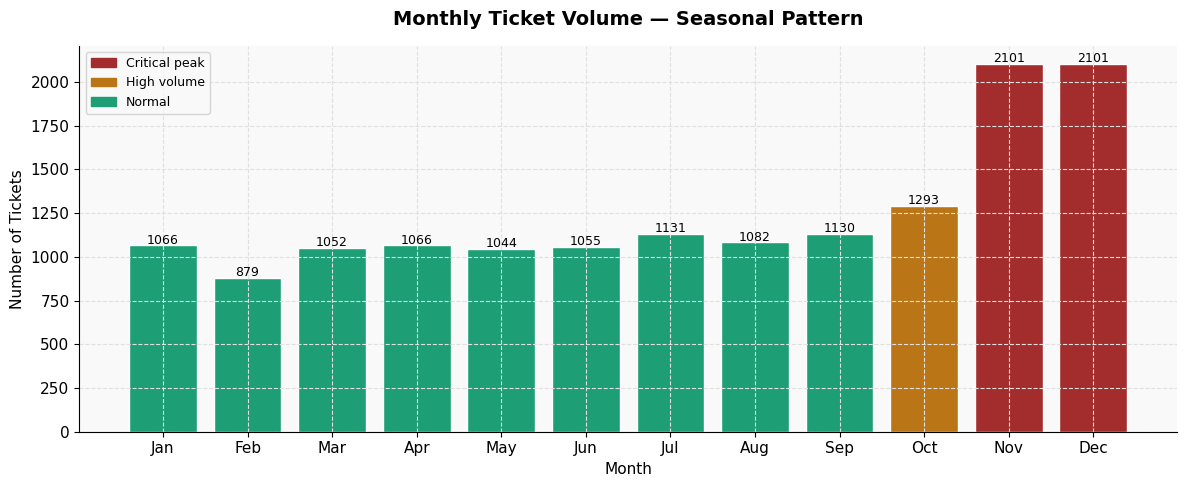

In [14]:
monthly_tickets = tickets.groupby('month')['ticket_id'].count().reset_index()
monthly_tickets.columns = ['month', 'ticket_count']
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_tickets['month_name'] = monthly_tickets['month'].apply(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = [
    COLORS['danger'] if m in [11, 12] else
    COLORS['warning'] if m in [10] else
    COLORS['primary']
    for m in monthly_tickets['month']
]
bars = ax.bar(monthly_tickets['month_name'], monthly_tickets['ticket_count'],
              color=bar_colors, edgecolor='white', linewidth=1)

for bar, val in zip(bars, monthly_tickets['ticket_count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', fontsize=9)

ax.set_title('Monthly Ticket Volume — Seasonal Pattern', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Tickets')
ax.legend(
    handles=[
        plt.Rectangle((0,0),1,1, color=COLORS['danger'], label='Critical peak'),
        plt.Rectangle((0,0),1,1, color=COLORS['warning'], label='High volume'),
        plt.Rectangle((0,0),1,1, color=COLORS['primary'], label='Normal')
    ], fontsize=9
)
plt.tight_layout()
plt.savefig('data/processed/chart_05_seasonal_tickets.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
peak = monthly_tickets[monthly_tickets['month'].isin([11,12])]['ticket_count'].mean()
avg  = monthly_tickets['ticket_count'].mean()
print('--- FINDING 4.2 ---')
print(f'November and December generate {peak:.0f} tickets on average vs {avg:.0f} monthly average.')
print(f'That is {((peak/avg)-1)*100:.0f}% more tickets during the same period revenue peaks.')
print()
print('IMPLICATION:')
print('The business faces a dangerous double pressure in Q4 — maximum revenue')
print('exposure coincides with maximum service demand. The risk of SLA breaches')
print('is highest precisely when the cost of customer dissatisfaction is greatest.')
print()
print('RECOMMENDATION:')
print('Pre-emptive Q4 resourcing plan: temporary staffing, extended hours,')
print('and simplified escalation paths implemented from October.')
print()
print('RISK OF INACTION:')
print('An unmanaged Q4 service spike directly threatens the revenue that')
print('defines annual business performance. Customer loss during peak season')
print('is also the hardest to recover — competitors are actively competing.')

--- FINDING 4.2 ---
November and December generate 2101 tickets on average vs 1250 monthly average.
That is 68% more tickets during the same period revenue peaks.

IMPLICATION:
The business faces a dangerous double pressure in Q4 — maximum revenue
exposure coincides with maximum service demand. The risk of SLA breaches
is highest precisely when the cost of customer dissatisfaction is greatest.

RECOMMENDATION:
Pre-emptive Q4 resourcing plan: temporary staffing, extended hours,
and simplified escalation paths implemented from October.

RISK OF INACTION:
An unmanaged Q4 service spike directly threatens the revenue that
defines annual business performance. Customer loss during peak season
is also the hardest to recover — competitors are actively competing.


---
## 5. Operational Performance

### 5.1 SLA Breach Rate by Location

In [16]:
loc_sla = tickets.groupby('location_id').agg(
    total_tickets=('ticket_id', 'count'),
    sla_breach_rate=('sla_breached', 'mean'),
    avg_csat=('csat_score', 'mean')
).round(3).reset_index().sort_values('sla_breach_rate', ascending=False)

print('SLA PERFORMANCE BY LOCATION')
print(loc_sla.to_string(index=False))

SLA PERFORMANCE BY LOCATION
location_id  total_tickets  sla_breach_rate  avg_csat
     LOC_03           2719            0.942     2.254
     LOC_07           2618            0.940     2.221
     LOC_04           1524            0.882     2.616
     LOC_05           1496            0.879     2.632
     LOC_02           1749            0.871     2.589
     LOC_06           1199            0.863     2.595
     LOC_08           1467            0.857     2.621
     LOC_01           2228            0.855     2.620


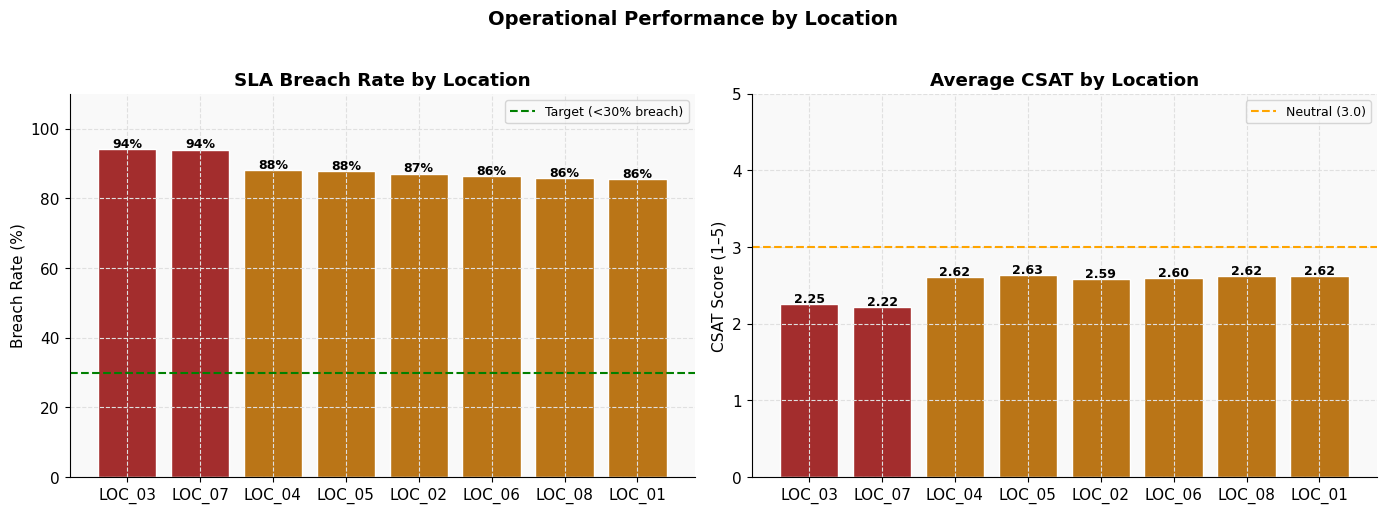

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

loc_colors = [
    COLORS['danger'] if r > 0.90 else
    COLORS['warning'] if r > 0.80 else
    COLORS['primary']
    for r in loc_sla['sla_breach_rate']
]

# SLA breach rate
bars = axes[0].bar(loc_sla['location_id'], loc_sla['sla_breach_rate'] * 100,
                   color=loc_colors, edgecolor='white')
axes[0].axhline(y=30, color='green', linestyle='--', linewidth=1.5, label='Target (<30% breach)')
for bar, val in zip(bars, loc_sla['sla_breach_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val*100:.0f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('SLA Breach Rate by Location', fontweight='bold')
axes[0].set_ylabel('Breach Rate (%)')
axes[0].set_ylim(0, 110)
axes[0].legend(fontsize=9)

# Avg CSAT by location
csat_colors = [
    COLORS['danger'] if s < 2.5 else
    COLORS['warning'] if s < 3.0 else
    COLORS['primary']
    for s in loc_sla['avg_csat']
]
bars2 = axes[1].bar(loc_sla['location_id'], loc_sla['avg_csat'],
                    color=csat_colors, edgecolor='white')
axes[1].axhline(y=3, color='orange', linestyle='--', linewidth=1.5, label='Neutral (3.0)')
for bar, val in zip(bars2, loc_sla['avg_csat']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Average CSAT by Location', fontweight='bold')
axes[1].set_ylabel('CSAT Score (1–5)')
axes[1].set_ylim(0, 5)
axes[1].legend(fontsize=9)

plt.suptitle('Operational Performance by Location', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/processed/chart_06_location_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
worst = loc_sla.iloc[0]
best  = loc_sla.iloc[-1]
print('--- FINDING 5.1 ---')
print(f"{worst['location_id']} has the highest SLA breach rate at {worst['sla_breach_rate']*100:.0f}%")
print(f"and the lowest CSAT at {worst['avg_csat']:.2f}.")
print(f"Best performing location {best['location_id']} breaches at {best['sla_breach_rate']*100:.0f}%.")
print()
print('IMPLICATION:')
print('LOC_03 and LOC_07 are not underperforming by a small margin — they are')
print('systematically failing. A 93%+ breach rate means almost no ticket is')
print('resolved within the SLA target. This is an operational crisis, not a dip.')
print('The CSAT correlation confirms customers at these locations are experiencing')
print('the worst service in the entire network.')
print()
print('RECOMMENDATION:')
print('Immediate operational review at LOC_03 and LOC_07 — staffing levels,')
print('escalation processes, and ticket routing must all be audited.')
print()
print('RISK OF INACTION:')
print('Every month LOC_03 and LOC_07 continue at current performance,')
print('the business is actively destroying customer satisfaction in two locations.')
print('These locations are Germany-based — a key European growth market.')

--- FINDING 5.1 ---
LOC_03 has the highest SLA breach rate at 94%
and the lowest CSAT at 2.25.
Best performing location LOC_01 breaches at 86%.

IMPLICATION:
LOC_03 and LOC_07 are not underperforming by a small margin — they are
systematically failing. A 93%+ breach rate means almost no ticket is
resolved within the SLA target. This is an operational crisis, not a dip.
The CSAT correlation confirms customers at these locations are experiencing
the worst service in the entire network.

RECOMMENDATION:
Immediate operational review at LOC_03 and LOC_07 — staffing levels,
escalation processes, and ticket routing must all be audited.

RISK OF INACTION:
Every month LOC_03 and LOC_07 continue at current performance,
the business is actively destroying customer satisfaction in two locations.
These locations are Germany-based — a key European growth market.


---
## 6. EDA Summary — Key Findings

In [19]:
print('=' * 65)
print('  EXPLORATORY ANALYSIS — KEY FINDINGS SUMMARY')
print('=' * 65)
print()
print('FINDING 1 — Revenue Seasonality')
print('  Nov-Dec revenue is significantly above monthly average.')
print('  Operational failures in Q4 carry the highest financial risk.')
print()
print('FINDING 2 — Geographic Concentration')
print(f'  UK generates {uk_pct}% of revenue — single market dependency risk.')
print('  Germany and France show growth potential.')
print()
print('FINDING 3 — Corporate Segment Value')
print(f'  Corporate CLV is {corp["avg_clv"]/retail["avg_clv"]:.0f}x higher than Retail.')
print('  Losing one corporate customer equals losing many retail customers.')
print()
print('FINDING 4 — Billing Complaints Most Damaging')
print(f'  Billing: {billing["avg_resolution_days"]:.1f} day avg resolution, {billing["avg_csat"]:.2f} CSAT.')
print('  Highest churn risk category in the dataset.')
print()
print('FINDING 5 — Q4 Service Demand Spike')
print(f'  Nov-Dec ticket volume is {((peak/avg)-1)*100:.0f}% above monthly average.')
print('  Peak revenue and peak service demand coincide — dangerous combination.')
print()
print('FINDING 6 — LOC_03 and LOC_07 Systematically Failing')
print(f'  93%+ SLA breach rate at both locations.')
print('  Both are Germany-based — undermining key growth market.')
print()
print('Next: Run Notebook 04 — Customer Experience Analysis')

  EXPLORATORY ANALYSIS — KEY FINDINGS SUMMARY

FINDING 1 — Revenue Seasonality
  Nov-Dec revenue is significantly above monthly average.
  Operational failures in Q4 carry the highest financial risk.

FINDING 2 — Geographic Concentration
  UK generates 86.3% of revenue — single market dependency risk.
  Germany and France show growth potential.

FINDING 3 — Corporate Segment Value
  Corporate CLV is 14x higher than Retail.
  Losing one corporate customer equals losing many retail customers.

FINDING 4 — Billing Complaints Most Damaging
  Billing: 8.3 day avg resolution, 1.96 CSAT.
  Highest churn risk category in the dataset.

FINDING 5 — Q4 Service Demand Spike
  Nov-Dec ticket volume is 68% above monthly average.
  Peak revenue and peak service demand coincide — dangerous combination.

FINDING 6 — LOC_03 and LOC_07 Systematically Failing
  93%+ SLA breach rate at both locations.
  Both are Germany-based — undermining key growth market.

Next: Run Notebook 04 — Customer Experience Ana